# Graph input for clonal embeddings construction

Some methods for batch correction or multimodal data representations don't give you a latent embedding that you can use to find nearest clonally labelled cells. For example, the result of multimodal integration with **Weighted Nearest Neighbors** algorithm is a graph, as well as the result of batch correction with **batch-balanced kNN**. It can be unclear how to build a matrix of clonal nearest neighbors in this case.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import clone2vec as c2v
import scanpy.external as sce

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

In this example, we're going to use a NSCLC cohort from Liu et al. In the original paper, authors used batch-balanced kNN to deal with the batch effect (in the clone2vec manuscript, we re-process the dataset with Harmony), so we can try to obtain similar to the original results and use it to build a clonal embedding.

In [2]:
adata = c2v.datasets.Liu_NSCLC_CD8(embedding_type="gex")

using gene expression embedding


In [3]:
sce.pp.bbknn(adata, use_rep="X_pca", n_pcs=30, batch_key="sample")

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:52)


In [4]:
sc.tl.umap(adata, min_dist=0.3)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:05:07)


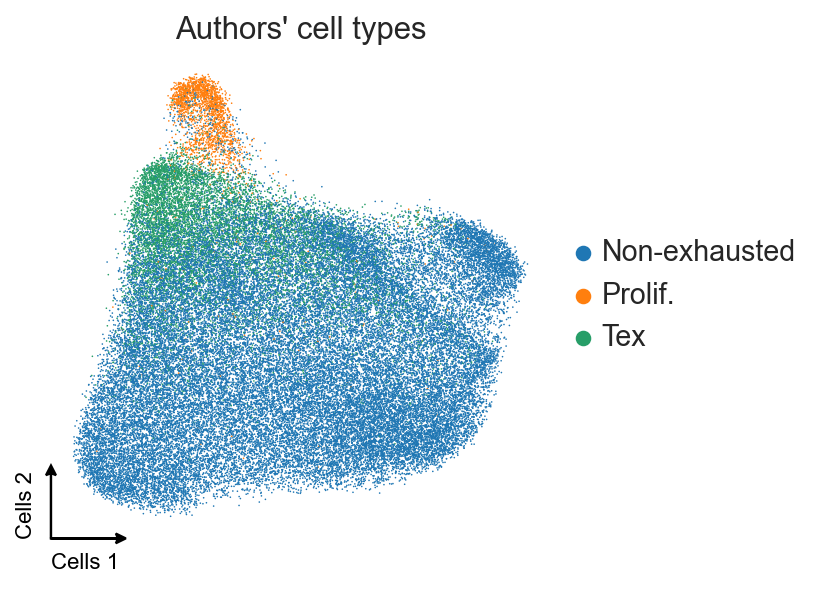

In [5]:
ax = sc.pl.umap(adata, color="cluster", frameon=False,
                title="Authors' cell types", show=False)

c2v.pl.embedding_axis(ax, label="Cells")

And now we will use the key trick – we're going to create a vector representation of the graph input using Leplacian eigenmaps.

In [6]:
c2v.utils.laplacian_eigenmaps(adata)

computing Laplacian eigenmaps: 
    using .obsp['connectivities'], n_components=20
    finished (0:00:16): added
     .obsm['X_laplacian'] Laplacian eigenmaps (20 components)
     .uns['laplacian_eigenmaps'] parameters


To create a clonal embedding, we will use a column `'full_clone'` from `adata.obs` – it contains also a site where clone was found, and a timepoint, so we will treat each `timepoint:site:clone` combination individually.

In [7]:
clones = c2v.pp.clones_adata(adata, obs_name="full_clone", min_size=3)

creating clone-level AnnData
    selected 1591 clones (>= 3)
    finished (0:00:01): created clones AnnData with
     .X float matrix of proportions (clones × categories)
     .layers['proportions'] float matrix with fate proportions
     .layers['counts'] integer matrix with fate counts
     .obs['n_cells'] integer vector with number of cells per clone
     .obs['n_fates'] integer vector with number of fates per clone
     .var['n_clones'] integer vector with number of clones per fate
     .uns['fill_obs'] string label


In [8]:
c2v.tl.clonal_nn(adata, clones, use_rep="X_laplacian")

computing clone-to-clone adjacency graph
    finished (0:00:38): added
     .obsp['gex_adjacency'] clone adjacency graph.
     .uns['clonal_nn'] parameters.


In [9]:
c2v.tl.clone2vec(clones)

fitting clone2vec embeddings
    SG epochs:  13%|█▎        | 63/500 [06:03<42:00,  5.77s/it, loss=5.0829, Δ=4.31e-05]
    early stopping at epoch 64
    finished (0:06:05): added
     .obsm['clone2vec'] embedding matrix
     .uns['clone2vec'] training details


In [10]:
sc.pp.neighbors(clones, use_rep="clone2vec")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


In [11]:
sc.tl.umap(clones)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


Now let's take a look at each clone's identity.

In [12]:
c2v.pp.transfer_annotation(adata, clones, annotation_obs_adata=["patient", "biospy_site", "treatment_hx"])

transferring annotations between cell and clone objects
    finished (0:00:00): added to clonal AnnData
     .obs['gex_patient'] categorical labels
     .obs['gex_biospy_site'] categorical labels
     .obs['gex_treatment_hx'] categorical labels


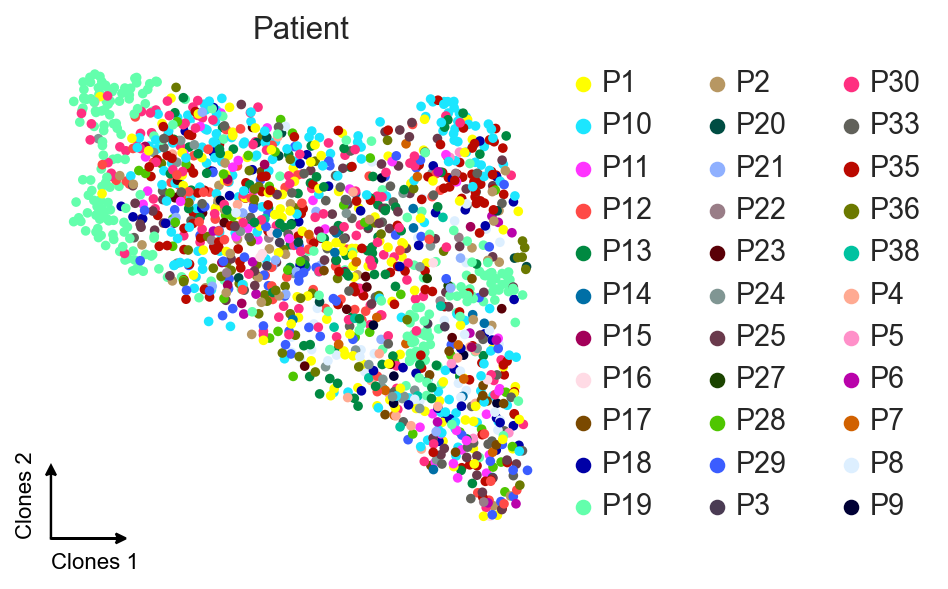

In [14]:
ax = sc.pl.umap(clones, color=["gex_patient"], frameon=False,
                title="Patient", show=False)

c2v.pl.embedding_axis(ax, label="Clones")

We see some minor propagation of the batch effect from the patient 19. We will take a closer look to it in the next notebook, for now let's leave it and find clonal clusters.

In [15]:
sc.tl.leiden(clones, resolution=0.2, flavor="igraph", n_iterations=2)

running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


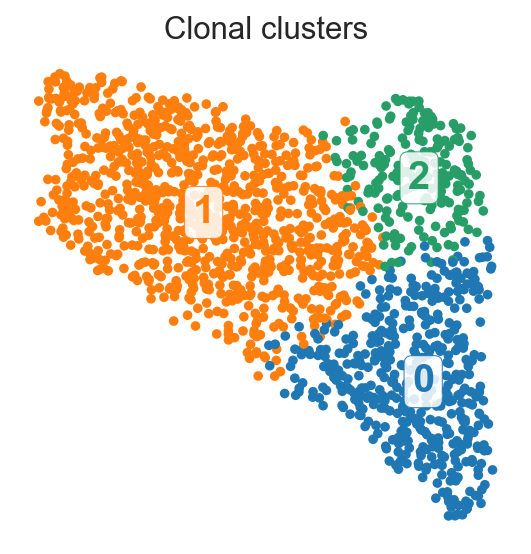

In [16]:
ax = sc.pl.umap(clones, color="leiden", title="Clonal clusters",
                frameon=False, show=False)

c2v.pl.fancy_legend(ax, textsize=18, center_loc=True, fontweight="bold")

We see three clonal clusters here – let's take a look at their projections on the gene expression embedding.

In [17]:
c2v.pp.transfer_annotation(adata, clones, annotation_obs_clones="leiden")

transferring annotations between cell and clone objects
    finished (0:00:00): added to clonal AnnData
     .obs['c2v_leiden'] categorical labels


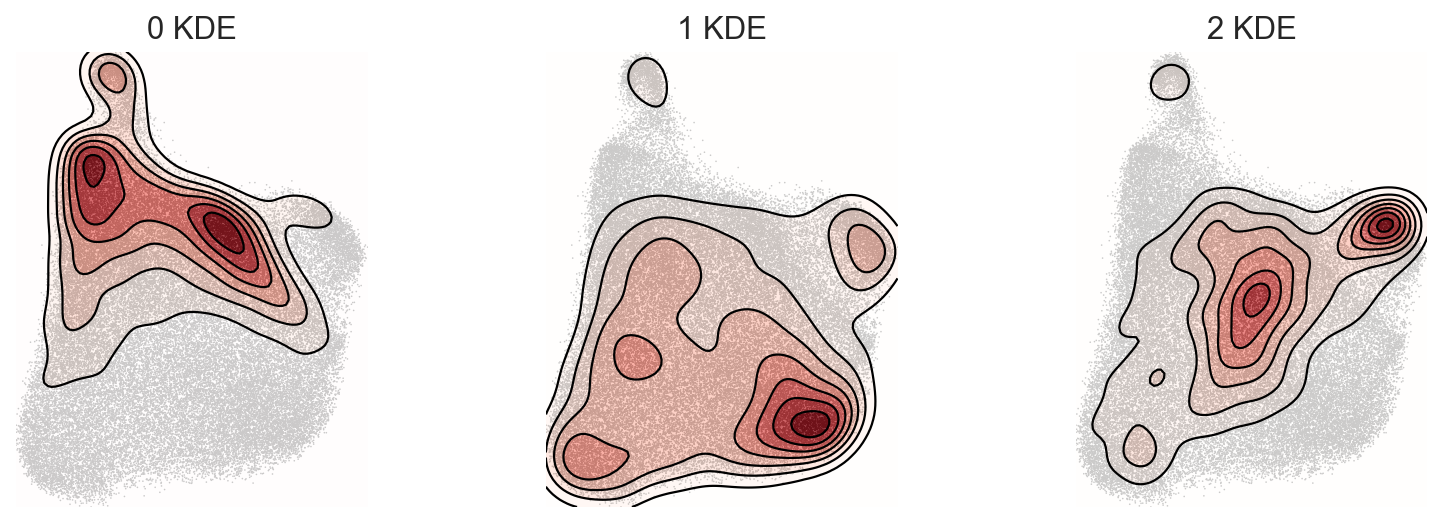

In [18]:
c2v.pl.group_kde(adata, groupby="c2v_leiden", groups=["0", "1", "2"], bw_method=0.2)

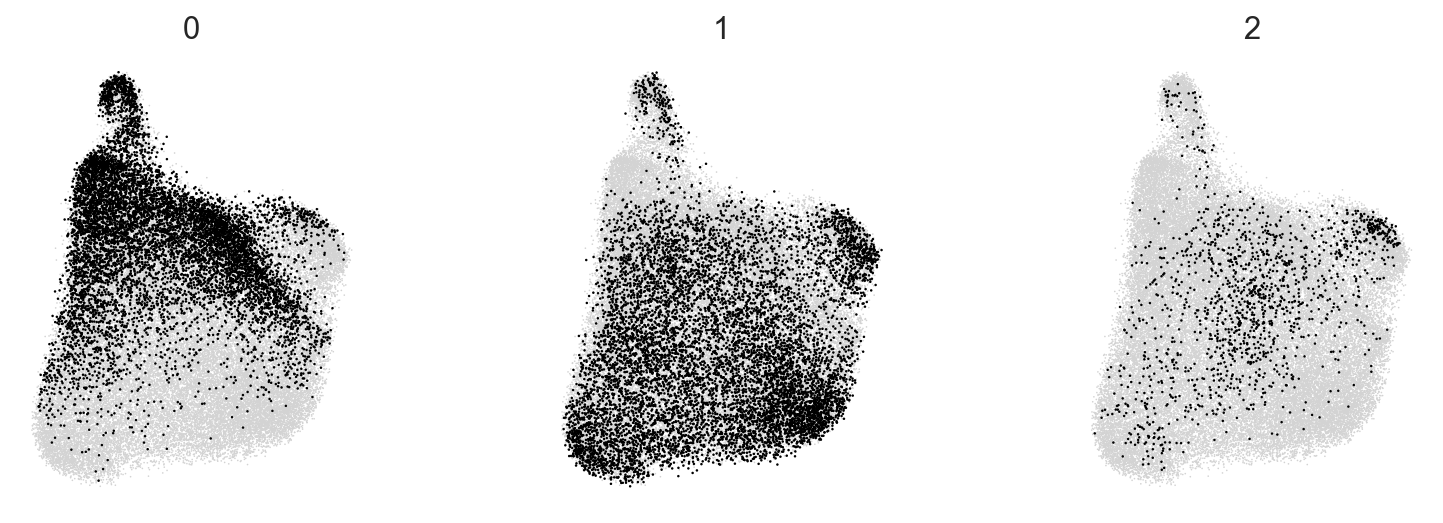

In [19]:
c2v.pl.group_scatter(adata, groupby="c2v_leiden", groups=["0", "1", "2"], s=5)

Finally, we can check if markers discovered in the paper are consistend with the clonal clusters constructed based on the bbknn-based gene expression embedding.

In [20]:
clones = c2v.pp.transfer_expression(adata, clones)

summarizing expression at clone level: 
    using `adata.X` as expression source
    finished (0:00:07): created clone-level AnnData with
     .X aggregated expression matrix (clones × genes)
     .uns['transfer_expression'] dict with 'strategy'
     .uns['mask_key'] string with obsm key for boolean mask of clones with non-zero cells
     .obsm['proportions'] dataframe of features
     .obsm['counts'] dataframe of features


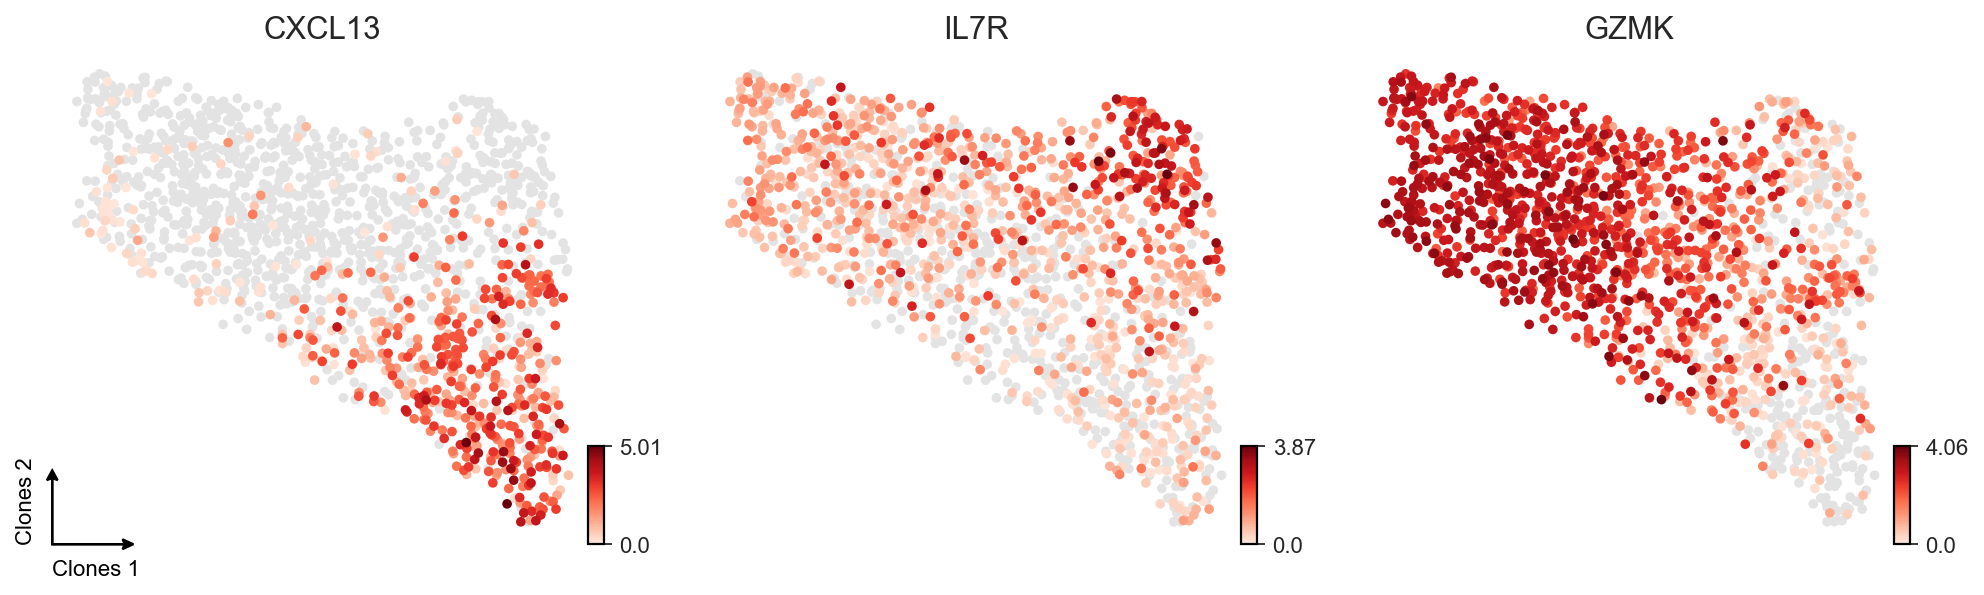

In [21]:
axes = sc.pl.umap(clones, color=["CXCL13", "IL7R", "GZMK"], frameon=False,
                  show=False, cmap=c2v.pl.Reds)
c2v.pl.small_cbar(axes)
c2v.pl.embedding_axis(axes[0], label="Clones")

/home/sergey/miniconda3/envs/sl/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


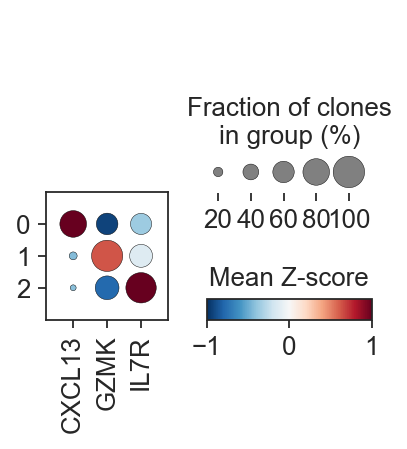

In [23]:
axes = c2v.pl.scaled_dotplot(
    clones,
    groupby="leiden",
    var_names=["CXCL13", "GZMK", "IL7R"],
    vmax=1,
    vmin=-1,
    size_title="Fraction of clones\nin group (%)",
)

In [24]:
clones.write_h5ad("Liu_CD8_bbknn_c2v.h5ad")